## 1. Physics-Informed Neural Network (PINN) 
Another possible way to solve the Black-Scholes model is through the use of machine learning. Partial Differential Equations (PDEs) are generally hard to solve and usually require numerical methods which can be computationally expensive. One approach currently being explored is a deep learning architecture known as a Physics-Informed Neural Network (PINN). This model is used to approximate the solutions to PDEs directly without a traditional mesh.

Given a general differential equation:

$$f(\vec{x}, t) = \frac{\partial u}{\partial t} + \mathcal{D}[u(\vec{x}, t)] = 0, \quad \vec{x} \in \Omega, \quad t \in [0, T]$$
 
where $\mathcal{D}$ is a non-linear differential operator. A neural network $\hat{u}(\vec{x},t; \theta)$ is trained to approximate the target function $u(\vec{x},t)$. The partial derivatives of $\hat{u}$ are calculated exactly using **Automatic Differentiation (AD)**. The total loss function for training the PINN is defined as:

$$MSE = MSE_u + MSE_f$$

$$MSE_u = \frac{1}{N_u} \sum_{i=1}^{N_u} \left| \hat{u}(\vec{x}_i^{(u)}, t_i^{(u)}; \theta) - u_i^{(u)} \right|^2$$

$$MSE_f = \frac{1}{N_f} \sum_{j=1}^{N_f} \left| f(\vec{x}_j^{(f)}, t_j^{(f)}; \theta) \right|^2$$

Where:
* $\hat{u}(\cdot; \theta)$ is the functional output of the neural network parameterized by weights and biases $\theta$.
* $(\vec{x}_i^{(u)}, t_i^{(u)})$ represent coordinates evaluated on the initial, terminal, or boundary constraints.
* $u_i^{(u)}$ represents the true specified value or target constraint at that point (e.g., terminal payoff).
* $f(\vec{x}_j^{(f)}, t_j^{(f)}; \theta)$ represents the residual evaluated at interior **collocation points**.

---

### References
* **Raissi et al. (2019):** *Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving partial differential equations.* [Journal of Computational Physics](https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125)
* **Louskos (2021):** *Physics-Informed Neural Networks for Pricing Financial Options.* [Dartmouth College Thesis](https://math.dartmouth.edu/theses/undergrad/2021/Louskos-thesis.pdf)
* **Makarov (2023):** *Applications of Physics-Informed Neural Networks in Financial Engineering.* [arXiv:2312.06711](https://arxiv.org/abs/2312.06711)


The model will be built using **PyTorch** and optimized using the built-in **Adam optimizer**.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
from model import PINN
random.seed(42)
torch.cuda.init()
torch.manual_seed(42)
torch.cuda.manual_seed(42)
warnings.filterwarnings(
    "ignore", 
    message="Attempting to run cuBLAS, but there was no current CUDA context!"
)

In [2]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
S_max = 3 * K  # Upper Boundary for S -> inf

#### 1.1 Data and Boundary Loss ($MSE_u$)
The term $MSE_u$ enforces the boundary conditions ($S = 0$ and $S = S_{\max}$) as well as the terminal payoff condition ($t = T$). It is calculated as:

$$MSE_u = MSE_{bc1} + MSE_{bc2} + MSE_{term}$$

Where each component represents an average over its respective sampled boundary points:

* **Lower Boundary ($S = 0$):**
  $$MSE_{bc1} = \frac{1}{N_{b}} \sum_{i=1}^{N_{b}} \left| \hat{C}(0, t_i^{(b)}; \theta) - 0 \right|^2$$

* **Upper Boundary ($S = S_{\max}$):**
  $$MSE_{bc2} = \frac{1}{N_{b}} \sum_{i=1}^{N_{b}} \left| \hat{C}(S_{\max}, t_i^{(b)}; \theta) - \left( S_{\max} - K e^{-r(T - t_i^{(b)})} \right) \right|^2$$

* **Terminal Condition ($t = T$):**
  $$MSE_{term} = \frac{1}{N_{term}} \sum_{i=1}^{N_{term}} \left| \hat{C}(S_i^{(term)}, T; \theta) - \max(S_i^{(term)} - K, 0) \right|^2$$

Here, $\hat{C}$ denotes the option price predicted by the neural network, $N_{b}$ is the number of boundary evaluation points, and $N_{term}$ is the number of terminal samples.

---

#### 1.2 Residual Loss ($MSE_f$)
The term $MSE_f$ evaluates how well the network honors the underlying Black-Scholes PDE across $N_f$ collocation points randomly sampled from the interior domain $(S, t) \in (0, S_{\max}) \times (0, T)$. 

We define the interior physics residual $f(S, t)$ using automatic differentiation:

$$f(S, t) := \frac{\partial \hat{C}}{\partial t} + r S \frac{\partial \hat{C}}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 \hat{C}}{\partial S^2} - r\hat{C}$$

The interior loss is the mean squared residual across all interior points:

$$MSE_f = \frac{1}{N_f} \sum_{j=1}^{N_f} \left| f(S_j^{(f)}, t_j^{(f)}; \theta) \right|^2$$

In [3]:
from function import collocation_points, plot_collocation, compute_pinn_loss, eval_model, plot_slices, generate_data

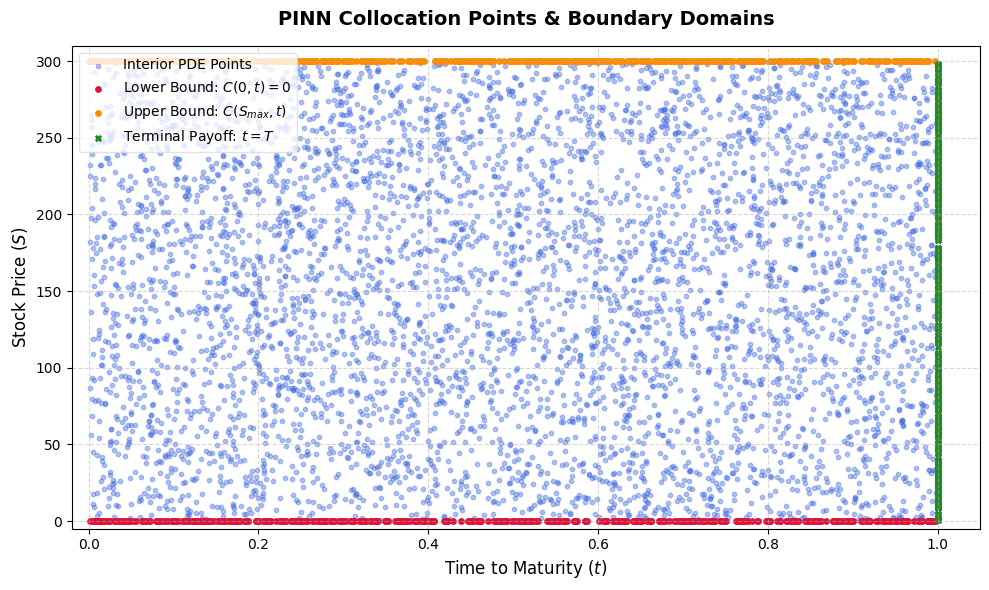

In [4]:
plot_collocation(S_max, T)

In [5]:
# Training PINN
def train_model_comp(data, model, optimizer, epochs):

    losses = []
    for epoch in range(epochs + 1):
        optimizer.zero_grad()
        
        # Compute the custom loss
        s, t = data
        loss = compute_pinn_loss(s, t, model)
        total_loss_tensor = sum(loss)
        total_loss = total_loss_tensor.item()
        if epoch % 500 == 0:
            print(
                f"Epoch {epoch:<5d} | "
                f"Total Loss: {total_loss:>12.6f} | "
                f"BC1 Loss: {loss[0].item():>12.6f} | "
                f"BC2 Loss: {loss[1].item():>12.6f} | "
                f"Terminal Loss: {loss[2].item():>12.6f} | "
                f"ODE Loss: {loss[3].item():>12.6f}"
            )

        losses.append(total_loss)

        total_loss_tensor.backward()
        optimizer.step()

    return losses

params = {'r': r, 'sigma': sigma, 'K' : K, 'T' : T}
model = PINN(params=params, in_features = 2, out_features = 1, layers=3, hidden_layers=64)
epochs = 3000
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
data = collocation_points(S_max, T, n_pde=5000, n_boundary=1000)
training_loss = train_model_comp(data, model, optimizer, epochs)

Epoch 0     | Total Loss: 50127.574219 | BC1 Loss:     0.011512 | BC2 Loss: 40946.187500 | Terminal Loss:  9181.375977 | ODE Loss:     0.000038
Epoch 500   | Total Loss:     7.106170 | BC1 Loss:     0.000560 | BC2 Loss:     1.112268 | Terminal Loss:     2.748136 | ODE Loss:     3.245205
Epoch 1000  | Total Loss:    29.738369 | BC1 Loss:     0.006953 | BC2 Loss:    21.852737 | Terminal Loss:     6.908819 | ODE Loss:     0.969861
Epoch 1500  | Total Loss:     6.643082 | BC1 Loss:     0.017093 | BC2 Loss:     1.362373 | Terminal Loss:     2.985964 | ODE Loss:     2.277653
Epoch 2000  | Total Loss:     5.281160 | BC1 Loss:     0.036339 | BC2 Loss:     2.128233 | Terminal Loss:     1.046610 | ODE Loss:     2.069979
Epoch 2500  | Total Loss:     2.790631 | BC1 Loss:     0.000701 | BC2 Loss:     0.831604 | Terminal Loss:     0.715426 | ODE Loss:     1.242900
Epoch 3000  | Total Loss:     7.531892 | BC1 Loss:     0.001716 | BC2 Loss:     2.647969 | Terminal Loss:     3.303261 | ODE Loss:     1

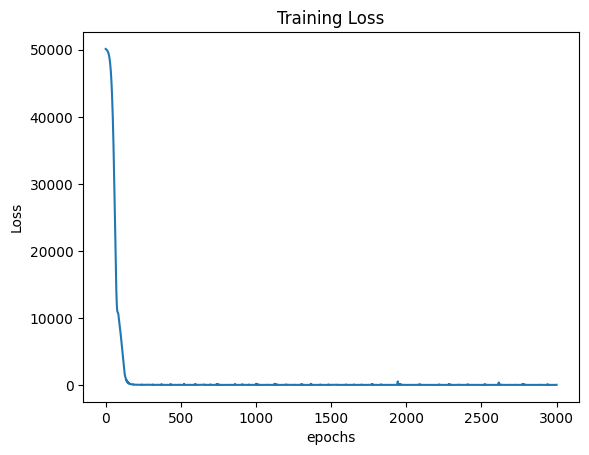

In [6]:
plt.plot(np.arange(0, epochs + 1), training_loss)
plt.ylabel("Loss")
plt.xlabel("epochs")
plt.title("Training Loss")
plt.show()

Parameter: r = 0.050, sigma = 0.200, K = 100.000


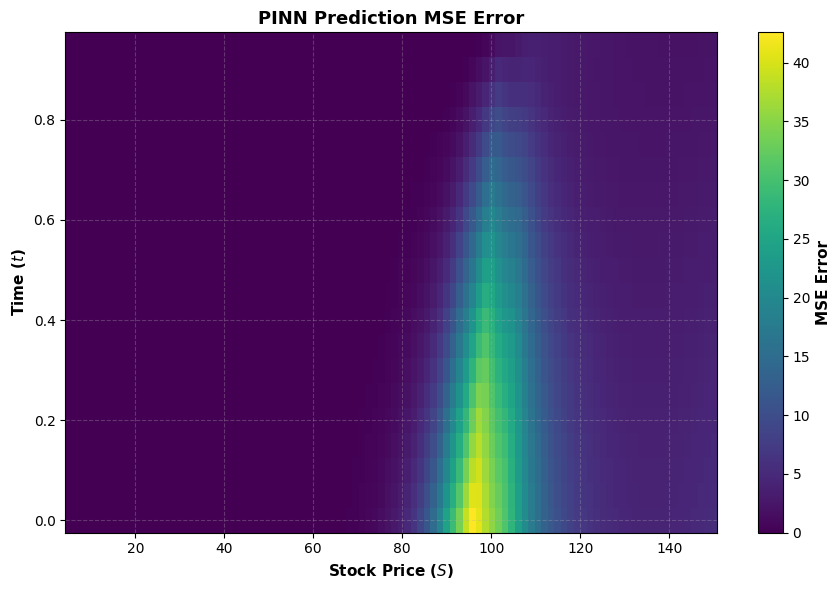

Total MSE Loss: 3.7687706487399937


In [7]:
eval_pts = generate_data(t_num=20, s_num=100)
print(f"Parameter: r = {r:.3f}, sigma = {sigma:.3f}, K = {K:.3f}")
print(f"Total MSE Loss: {eval_model(r, sigma, K, T, eval_pts, model, True)}")

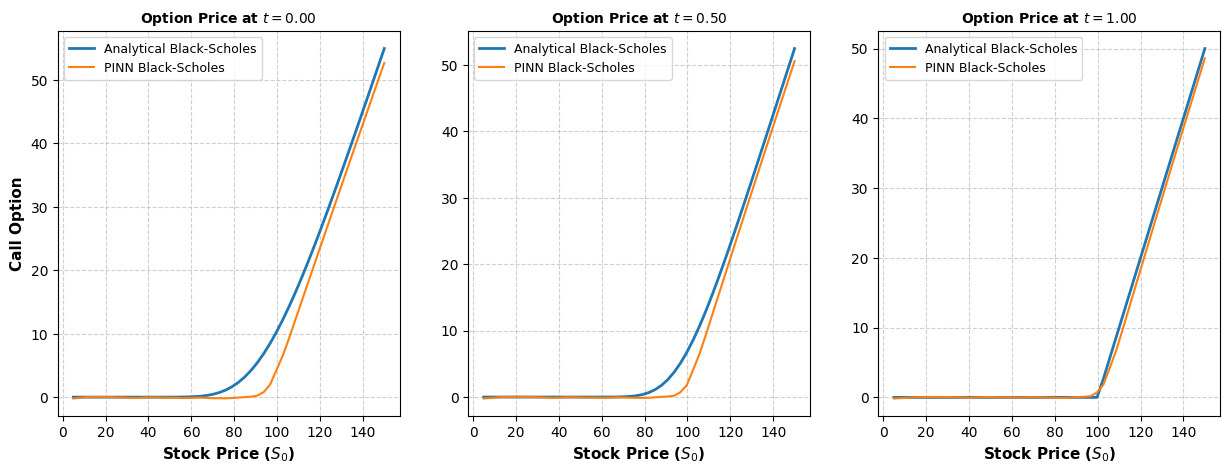

In [8]:
plot_slices(r, sigma, K, T, n_slice=3, model=model)

## Optimization

Standard PINN training often exhibits large initial loss and slow convergence, leading to inaccurate Black-Scholes estimations. This is likely caused by an ill-conditioned loss landscape.

### Key Observations

* **Optimizer Performance:** First-order methods like SGD and AdaGrad struggle to converge on PINN loss surfaces.
* **Recommended Approaches:** Literature suggests using **Adam**, **L-BFGS**, or a hybrid **Adam + L-BFGS** strategy.
* **Curvature Analysis:** To understand training dynamics and stiffness, loss landscape can be analyze by computing the spectral density (eigenvalues) of the Hessian matrix at different parts of training.

---

### References
* [PyHessian for Neural Network Analysis (Yao et al., 2019)](https://arxiv.org/abs/1912.07145)
* [Challenges in Training PINNs: A Loss Landscape Perspective](https://arxiv.org/abs/2402.01868)

In [9]:
from pyhessian import hessian
from pyhessian import get_esd_plot

In [10]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
S_max = 3 * K  # Upper Boundary for S -> inf

params = {'r': r, 'sigma': sigma, 'K' : K, 'T' : T}
data = collocation_points(S_max, T, n_pde=5000, n_boundary=500)
new_model = PINN(params)

In [11]:
def check_esd(model, compute_pinn_loss, data, optimizer, device='cuda'):

    esd_plot = []
    for epoch in range(epochs + 1):
        optimizer.zero_grad()
        
        # Compute the custom loss
        s, t = data
        loss = compute_pinn_loss(s, t, model)
        total_loss_tensor = sum(loss)
        total_loss = total_loss_tensor.item()
        if epoch % 500 == 0:
            print(
                f"Epoch {epoch:<5d} | "
                f"Total Loss: {total_loss:>12.6f} | "
                f"BC1 Loss: {loss[0].item():>12.6f} | "
                f"BC2 Loss: {loss[1].item():>12.6f} | "
                f"Terminal Loss: {loss[2].item():>12.6f} | "
                f"ODE Loss: {loss[3].item():>12.6f}"
            )

        total_loss_tensor.backward()
        optimizer.step()

        if epoch % 1500 == 0:
            h = hessian(model, compute_pinn_loss, data, device)
            eigen_list_full, weight_list_full = h.density()
            esd_plot.append([eigen_list_full, weight_list_full, epoch])
        
    return esd_plot
    

Epoch 0     | Total Loss: 50937.730469 | BC1 Loss:     0.006215 | BC2 Loss: 41043.433594 | Terminal Loss:  9894.290039 | ODE Loss:     0.000046
Epoch 500   | Total Loss:    18.133671 | BC1 Loss:     0.001184 | BC2 Loss:     1.871141 | Terminal Loss:     9.925935 | ODE Loss:     6.335412
Epoch 1000  | Total Loss:     2.429397 | BC1 Loss:     0.000203 | BC2 Loss:     0.334615 | Terminal Loss:     0.168197 | ODE Loss:     1.926382
Epoch 1500  | Total Loss:     2.353070 | BC1 Loss:     0.000062 | BC2 Loss:     0.340147 | Terminal Loss:     0.156639 | ODE Loss:     1.856221
Epoch 2000  | Total Loss:   230.506683 | BC1 Loss:     0.629115 | BC2 Loss:     1.439608 | Terminal Loss:   175.991486 | ODE Loss:    52.446472
Epoch 2500  | Total Loss:     1.721329 | BC1 Loss:     0.000148 | BC2 Loss:     0.138672 | Terminal Loss:     0.121888 | ODE Loss:     1.460622
Epoch 3000  | Total Loss:     4.031394 | BC1 Loss:     0.008324 | BC2 Loss:     1.122199 | Terminal Loss:     0.622921 | ODE Loss:     2

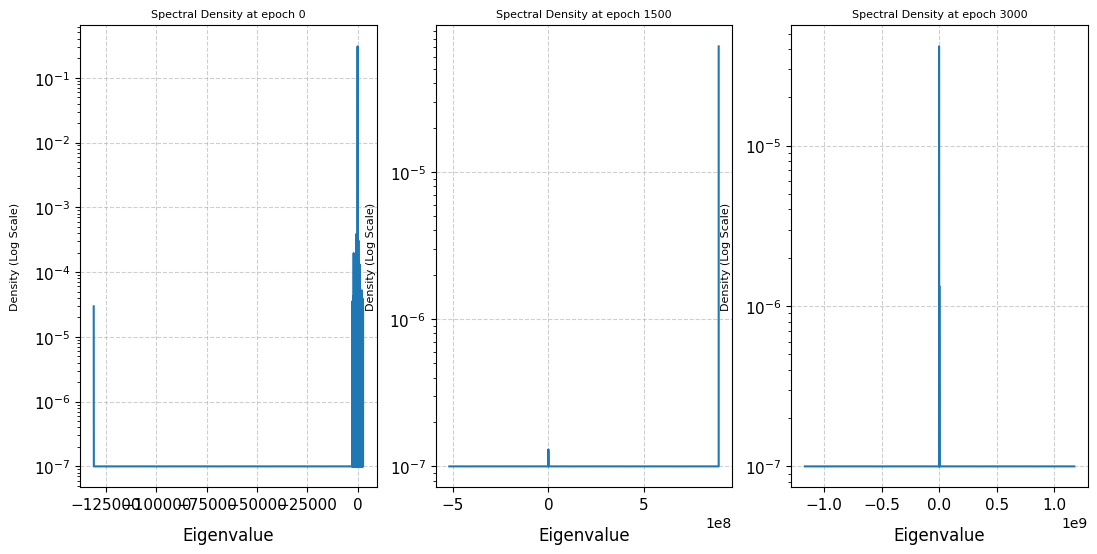

In [12]:
epochs = 4500
optimizer = torch.optim.Adam(new_model.parameters(), lr=0.001)
esd_plot = check_esd(new_model, compute_pinn_loss, data, optimizer, device='cuda')
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(13, 6))
ax = axs.flatten()
for i in range(3):
    eigenvalues = esd_plot[i][0]
    weights = esd_plot[i][1]
    epoch = esd_plot[i][2]
    print(f"Epoch: {epoch} Max Eigenvalue: {max(eigenvalues[0])}, Min Eigenvalue: {min(eigenvalues[0])}")
    density, grids  = get_esd_plot(eigenvalues, weights)
    ax[i].semilogy(grids, density + 1.0e-7)
    ax[i].set_title(f'Spectral Density at epoch {epoch}', fontsize=8)
    ax[i].set_ylabel('Density (Log Scale)', fontsize=8, labelpad=10)
    ax[i].set_xlabel('Eigenvalue', fontsize=12, labelpad=10)
    ax[i].tick_params(axis='both', which='major', labelsize=11)
    ax[i].grid(True, linestyle='--', alpha=0.6)

In [13]:
from optim import optim_tune

In [14]:
num_models = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models = [PINN(params).to(device) for _ in range(num_models)]
data = collocation_points(S_max, T, n_pde=5000, n_boundary=500)

configs = {
    "Adam": {
        "model": models[0],
        "optimizer": torch.optim.Adam(models[0].parameters(), lr=0.001),
        "epochs": 4000
    },
    "LBFGS_wolfe": {
        "model": models[1],
        "optimizer": torch.optim.LBFGS(models[1].parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe"),
        "epochs": 200
    },
    "AdaGrad": {
        "model": models[2],
        "optimizer": torch.optim.Adagrad(models[2].parameters(), lr=0.001),
        "epochs": 4000
    },
    "Adam+LBFGS" : {
        "model": models[3],
        "optimizer_LBFGS": torch.optim.LBFGS(models[3].parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe"),
        "optimizer_Adam" : torch.optim.Adam(models[3].parameters(), lr=0.001),
        "epochs_Adam": 1000,
        "epochs_LBFGS" : 150,
    }
}

In [15]:
results = optim_tune(configs, data)

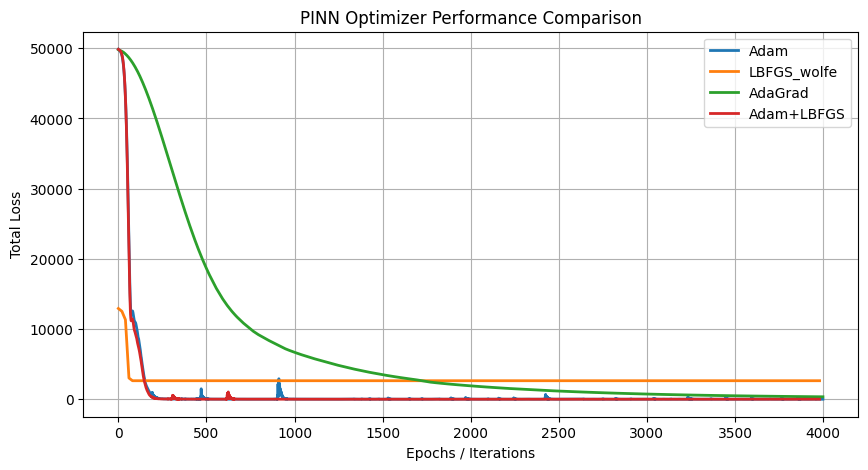

In [16]:
plt.figure(figsize=(10, 5))
for name, data in results.items():
    plt.plot(data["x"], data["y"], label=name, linewidth=2)
plt.xlabel('Epochs / Iterations')
plt.ylabel('Total Loss')
plt.title('PINN Optimizer Performance Comparison')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

In [17]:
for name, data in results.items():
    print(f'Loss ({name}): {data["y"][-1]}')

print(f"Best_Optimizer: {min(results, key=lambda item: item[-1])}")

Loss (Adam): 2.9372715950012207
Loss (LBFGS_wolfe): 2637.015106201172
Loss (AdaGrad): 347.3206787109375
Loss (Adam+LBFGS): 1.2136397017166018
Best_Optimizer: Adam+LBFGS


## Hyperparameter Tuning
By testing different optimizer strategy the approach on Adam + LBFGS gives the lowest training loss and converge faster. Gridsearch is used here for tuning the model, the mse of each model is compute through the 9 slices of surface and the lowest mse is chosen

In [18]:
from optim import gridsearch

In [19]:
# Parameter for training model
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
S_max = 3 * K

grid = {
    'lr' : [0.01, 0.001, 0.0001],
    'layers' : [4, 5],
    'epochs_Adam': [1000],
    'epochs_LBFGS': [150],
    'hidden_layers' : [60, 80]
}

training_data = collocation_points(S_max, T, n_pde=5000, n_boundary=1000)
training_params = {'r': r, 'sigma': sigma, 'K' : K, 'T' : T}
testing_data = generate_data(t_num=100, s_num=100)
testing_params = [r, sigma, K, T]
models = gridsearch(grid, training_data, training_params, testing_data, testing_params)
best_model, mse_loss = min(models, key=lambda x: x[1])

Num of Configs 12
Training configs 1
Training configs 2
Training configs 3
Training configs 4
Training configs 5
Training configs 6
Training configs 7
Training configs 8
Training configs 9
Training configs 10
Training configs 11
Training configs 12


Parameter: r = 0.050, sigma = 0.200, K = 100.000


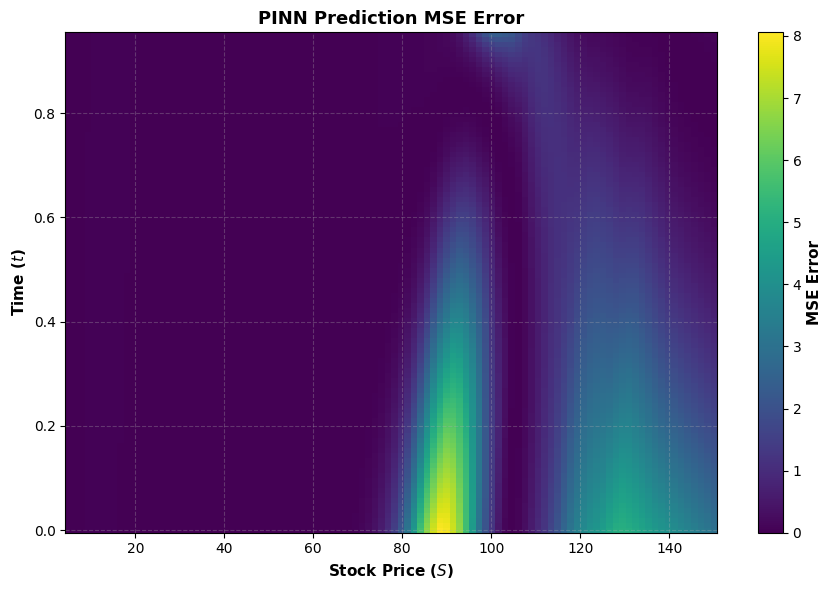

Total MSE Loss: 0.7536968035654726


In [20]:
device = "cuda"
print(f"Parameter: r = {r:.3f}, sigma = {sigma:.3f}, K = {K:.3f}")
print(f"Total MSE Loss: {eval_model(r, sigma, K, T, testing_data, best_model.to(device), True)}")

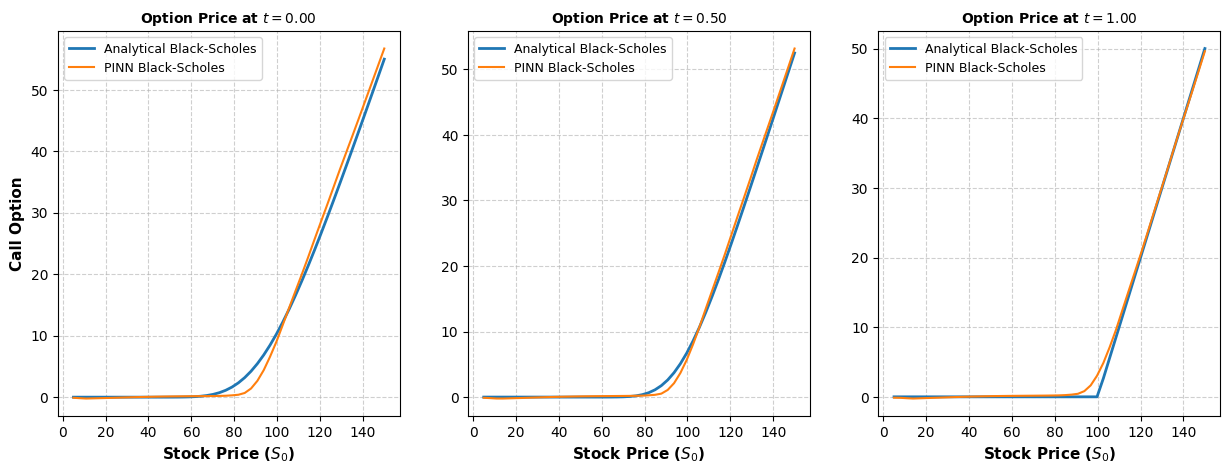

In [22]:
plot_slices(r, sigma, K, T, n_slice=3, model=best_model)